In [ ]:
import os

# Ensure relative paths resolve from repo root when run via nbconvert
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [1]:
# Imports
import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np
import pandas as pd
import time
import os
from scipy.stats import norm, probplot, gaussian_kde
from dlci.core import LongitudinalOPEData
from dlci.nested_dr_kpt import NestedDRKPT
from dlci.longitudinal_datasets import LongitudinalSyntheticDataset
from dlci.viz import plot_null_diagnostics, plot_power
from tqdm import tqdm

In [2]:
def run_longitudinal_tests(
    scenario_list,
    method_list,
    sample_size_list,
    num_experiments,
    name_folder,
    K=1,
    d=5,
    tune_lambda=True,
    reg_lambda_default=1e-2,
    pilot_seed=999,
):
    os.makedirs(name_folder, exist_ok=True)

    for scenario_id in tqdm(scenario_list, desc="scenarios"):
        print(f"Scenario {scenario_id}")
        for ns in tqdm(
            sample_size_list, desc=f"  ns (scenario {scenario_id})", leave=False
        ):
            # Tune reg_lambda once per (scenario, ns) on a pilot dataset
            if tune_lambda:
                pilot_ds = LongitudinalSyntheticDataset(
                    scenario_id, K=K, ns=ns, d=d, seed=pilot_seed
                )
                pilot_data = pilot_ds.prepare_ope_data(
                    pilot_ds.pi_policies, pilot_ds.pi_prime_policies
                )
                reg_lambda = NestedDRKPT.tune_reg_lambda(
                    pilot_data.L[-1], pilot_data.A[-1], pilot_data.Y
                )
                print(f"  ns={ns}: tuned reg_lambda={reg_lambda:.4g}")
            else:
                reg_lambda = reg_lambda_default

            nested_cf = NestedDRKPT(reg_lambda=reg_lambda, cross_fit=True)
            nested_full = NestedDRKPT(reg_lambda=reg_lambda, cross_fit=False)

            for method in method_list:
                p_values = np.zeros(num_experiments)
                stats = np.zeros(num_experiments)
                times = np.zeros(num_experiments)

                for seed in tqdm(
                    range(num_experiments),
                    desc=f"    seeds (ns={ns}, {method})",
                    leave=False,
                ):
                    ds = LongitudinalSyntheticDataset(
                        scenario_id, K=K, ns=ns, d=d, seed=seed
                    )
                    data = ds.prepare_ope_data(ds.pi_policies, ds.pi_prime_policies)

                    try:
                        t0 = time.time()
                        if method == "NestedDR-CF":
                            result = nested_cf.test(data)
                        elif method == "NestedDR":
                            result = nested_full.test(data)
                        else:
                            raise ValueError(f"Unknown method: {method}")
                        stat, pval = result["stat"], result["pval"]
                        elapsed = time.time() - t0
                    except Exception as e:
                        print(f"  seed={seed} method={method} ns={ns}: {e}")
                        stat, pval, elapsed = np.nan, np.nan, 0.0

                    p_values[seed] = pval
                    stats[seed] = stat
                    times[seed] = elapsed

                df = pd.DataFrame({"p_value": p_values, "stat": stats, "time": times})
                fname = f"{name_folder}/ns{ns}_longitudinal_scenario{scenario_id}_{method}.csv"
                df.to_csv(fname, index=False)
                print(f"    Saved: {fname}")

In [3]:
# Scenario I (null) — false positive rate calibration
run_longitudinal_tests(
    scenario_list=["I"],
    method_list=["NestedDR-CF"],
    sample_size_list=[100, 200, 300, 400],
    num_experiments=10,
    name_folder="results",
)


scenarios:   0%|          | 0/1 [00:00<?, ?it/s]

Scenario I



  ns (scenario I):   0%|          | 0/4 [00:00<?, ?it/s]

  ns=100: tuned reg_lambda=0.001



    seeds (ns=100, NestedDR-CF):   0%|          | 0/10 [00:00<?, ?it/s]

...


    seeds (ns=400, NestedDR-CF): 100%|██████████| 10/10 [00:07<00:00,  1.43it/s]


  ns (scenario I): 100%|██████████| 4/4 [00:15<00:00,  5.14s/it]


scenarios: 100%|██████████| 1/1 [00:15<00:00, 15.92s/it]


scenarios: 100%|██████████| 1/1 [00:15<00:00, 15.92s/it]

    Saved: results/ns400_longitudinal_scenarioI_NestedDR-CF.csv


In [4]:
# Scenarios II, III, IV — power curves
run_longitudinal_tests(
    scenario_list=["II", "III", "IV"],
    method_list=["NestedDR-CF"],
    sample_size_list=[100, 200, 300, 400],
    num_experiments=10,
    name_folder="results",
)


scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Scenario II



  ns (scenario II):   0%|          | 0/4 [00:00<?, ?it/s]

  ns=100: tuned reg_lambda=0.001



    seeds (ns=100, NestedDR-CF):   0%|          | 0/10 [00:00<?, ?it/s]

...


    seeds (ns=400, NestedDR-CF): 100%|██████████| 10/10 [00:07<00:00,  1.28it/s]


  ns (scenario IV): 100%|██████████| 4/4 [00:19<00:00,  6.04s/it]


scenarios: 100%|██████████| 3/3 [01:02<00:00, 21.00s/it]


scenarios: 100%|██████████| 3/3 [01:02<00:00, 20.77s/it]

    Saved: results/ns400_longitudinal_scenarioIV_NestedDR-CF.csv


In [5]:
# Load all longitudinal results
import glob


def load_longitudinal_results(folder="results/"):
    files = glob.glob(f"{folder}*longitudinal*.csv")
    return {f: pd.read_csv(f) for f in files}


d_results = load_longitudinal_results("results/")
print(f"Loaded {len(d_results)} result files")

Loaded 27 result files


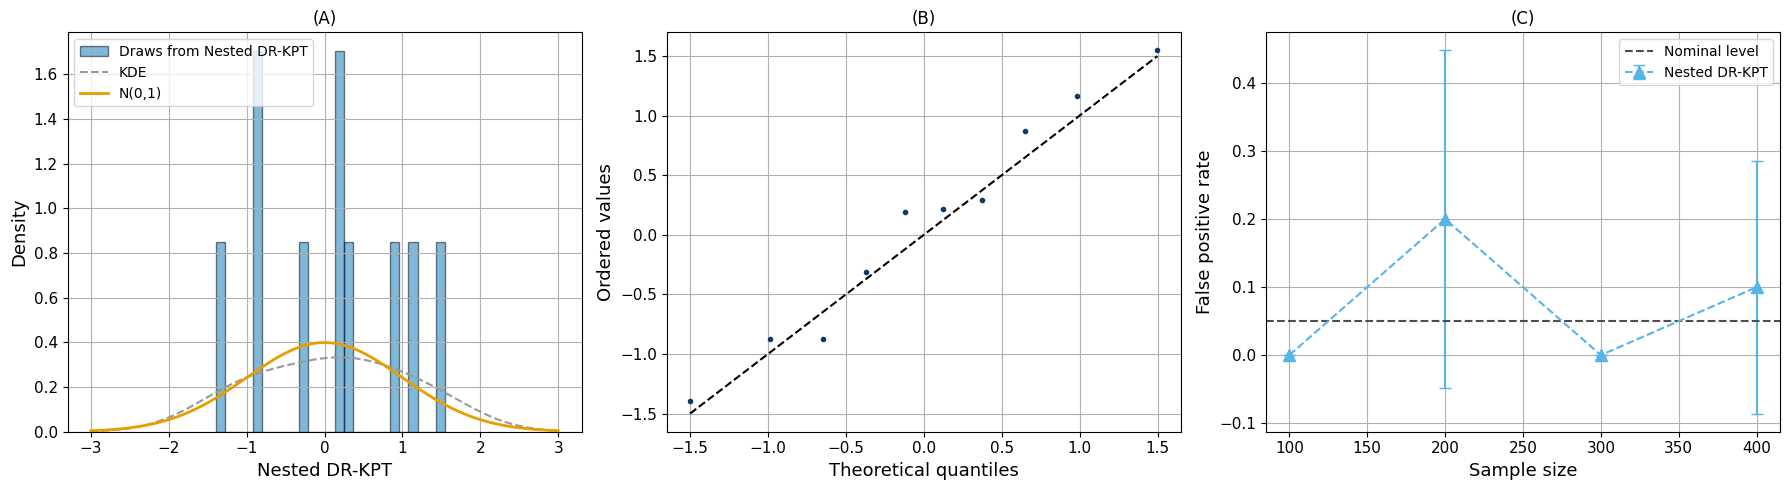

In [6]:
plot_null_diagnostics(
    d_results,
    scenario="I",
    method="NestedDR-CF",
    ns=300,
    results_folder="results/",
    ns_list=[100, 200, 300, 400],
    confidence_level=0.05,
    save_path="plots/null_longitudinal_scenarioI_errorbar.pdf",
    longitudinal=True,
)

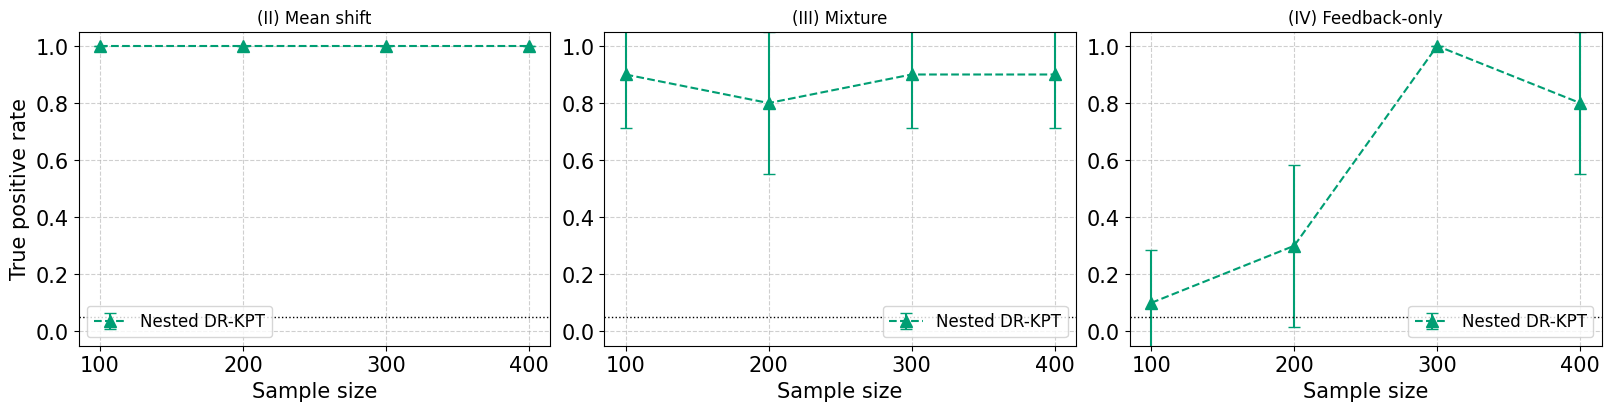

In [7]:
plot_power(
    d=d_results,
    scenario_list=["II", "III", "IV"],
    methods=["NestedDR-CF"],
    ns_list=[100, 200, 300, 400],
    results_folder="results/",
    confidence_level=0.05,
    save_path="plots/longitudinal_scenarios234_errorbar.pdf",
    longitudinal=True,
)

In [8]:
# Scenario IV comparison: NestedDR-CF vs non-nested DR-CF
# Requires running the non-nested DR-CF on the longitudinal Scenario IV data first.
# This cell runs both and overlays them on a single power plot.
#
# NOTE: to add DR-CF (non-nested) as a baseline, run:
#   from dlci.dr_kpt import DRKPT
#   from dlci.datasets import ... (wrap LongitudinalOPEData to flat OPEData using only stage K)
#
# This is left as a separate cell to be completed once baseline comparison data is generated.

print(
    "Scenario IV comparison cell: run non-nested baseline separately, then overlay plots."
)

Scenario IV comparison cell: run non-nested baseline separately, then overlay plots.
